In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/datasets/x_ray.zip'
extract_path = '/content/x_ray_all'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['x_ray']


In [ ]:
data_path = '/content/x_ray_all/x_ray'

print(os.listdir(data_path))

['PNEUMONIA', 'NORMAL']


In [ ]:
import os
import shutil
import random

random.seed(42)

source_path = '/content/x_ray_all/x_ray'
output_path = '/content/x_ray_split'

classes = ['NORMAL', 'PNEUMONIA']

for split in ['train', 'validation', 'test']:
    for class_name in classes:
        os.makedirs(
            os.path.join(output_path, split, class_name),
            exist_ok=True
        )

for class_name in classes:

    class_path = os.path.join(source_path, class_name)
    images = os.listdir(class_path)

    random.shuffle(images)

    total = len(images)

    train_end = int(total * 0.70)
    val_end = int(total * 0.85)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for img in train_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(output_path, 'train', class_name, img)
        )

    for img in val_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(output_path, 'validation', class_name, img)
        )

    for img in test_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(output_path, 'test', class_name, img)
        )

    print(
        class_name,
        "→",
        "Train:", len(train_images),
        "Validation:", len(val_images),
        "Test:", len(test_images)
    )

NORMAL → Train: 1108 Validation: 237 Test: 238
PNEUMONIA → Train: 2991 Validation: 641 Test: 641


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    '/content/x_ray_split/train',
    target_size=(224,224),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=32,
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    '/content/x_ray_split/validation',
    target_size=(224,224),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=32,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    '/content/x_ray_split/test',
    target_size=(224,224),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=32,
    shuffle=False
)

Found 4099 images belonging to 2 classes.
Found 878 images belonging to 2 classes.
Found 879 images belonging to 2 classes.


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D, Dense, Dropout
)

model = Sequential([
    Input(shape=(224,224,1)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '/content/best_cnn.keras',
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
callbacks=[reduce_lr, early_stopping , checkpoint]
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 99s 564ms/step - accuracy: 0.8700 - loss: 0.3040 - val_accuracy: 0.7301 - val_loss: 6.3439 - learning_rate: 0.0010
Epoch 2/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 56s 437ms/step - accuracy: 0.8927 - loss: 0.2713 - val_accuracy: 0.7301 - val_loss: 4.0085 - learning_rate: 0.0010
Epoch 3/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 56s 436ms/step - accuracy: 0.8983 - loss: 0.2435 - val_accuracy: 0.7301 - val_loss: 2.8470 - learning_rate: 0.0010
Epoch 4/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 56s 436ms/step - accuracy: 0.9151 - loss: 0.2264 - val_accuracy: 0.9100 - val_loss: 0.2633 - learning_rate: 0.0010
Epoch 5/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 56s 437ms/step - accuracy: 0.9246 - loss: 0.1999 - val_accuracy: 0.7301 - val_loss: 0.9830 - learning_rate: 0.0010
Epoch 6/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9308 - loss: 0.1854
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
129/129 ━━━━━━━━━━━━━━━━━━━━ 57s 442ms/step - accuracy: 0.928

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 341ms/step - accuracy: 0.9056 - loss: 0.2363
Test Loss: 0.2362969070672989
Test Accuracy: 0.9055745005607605


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=['NORMAL', 'PNEUMONIA']
    )
)

28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 278ms/step
Confusion Matrix:
[[184  54]
 [ 29 612]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.86      0.77      0.82       238
   PNEUMONIA       0.92      0.95      0.94       641

    accuracy                           0.91       879
   macro avg       0.89      0.86      0.88       879
weighted avg       0.90      0.91      0.90       879



In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_generator.classes)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(zip(classes, class_weights))

print(class_weights)

{np.int32(0): np.float64(1.8497292418772564), np.int32(1): np.float64(0.6852223336676697)}


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras.optimizers import Adam

model_cw = Sequential([
    Input(shape=(224,224,1)),

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_cw.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cw.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             

 Total params: 1,241,569 (4.74 MB)

 Trainable params: 1,239,649 (4.73 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stopping_cw = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_cw = ModelCheckpoint(
    '/content/best_cnn_cw.keras',
    monitor='val_loss',
    save_best_only=True
)

reduce_lr_cw = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
history_cw = model_cw.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[
        early_stopping_cw,
        checkpoint_cw,
        reduce_lr_cw
    ]
)

Epoch 1/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 74s 487ms/step - accuracy: 0.8573 - loss: 0.3395 - val_accuracy: 0.7301 - val_loss: 2.3370 - learning_rate: 0.0010
Epoch 2/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 56s 433ms/step - accuracy: 0.8817 - loss: 0.2902 - val_accuracy: 0.6913 - val_loss: 2.1308 - learning_rate: 0.0010
Epoch 3/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 56s 434ms/step - accuracy: 0.8834 - loss: 0.2629 - val_accuracy: 0.7301 - val_loss: 3.0784 - learning_rate: 0.0010
Epoch 4/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 56s 436ms/step - accuracy: 0.9031 - loss: 0.2402 - val_accuracy: 0.7323 - val_loss: 0.7079 - learning_rate: 0.0010
Epoch 5/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 56s 434ms/step - accuracy: 0.9012 - loss: 0.2448 - val_accuracy: 0.7301 - val_loss: 0.8818 - learning_rate: 0.0010
Epoch 6/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9109 - loss: 0.2298
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
129/129 ━━━━━━━━━━━━━━━━━━━━ 56s 433ms/step - accuracy: 0.909

In [ ]:
import os
import random
import shutil

source_path = '/content/x_ray_all/x_ray'
downsampled_path = '/content/x_ray_downsampled'

if os.path.exists(downsampled_path):
    shutil.rmtree(downsampled_path)

os.makedirs(f'{downsampled_path}/NORMAL')
os.makedirs(f'{downsampled_path}/PNEUMONIA')

random.seed(42)

normal_images = os.listdir(f'{source_path}/NORMAL')
pneumonia_images = os.listdir(f'{source_path}/PNEUMONIA')

random.shuffle(normal_images)
random.shuffle(pneumonia_images)

# Equal number of images
n = min(len(normal_images), len(pneumonia_images))

normal_images = normal_images[:n]
pneumonia_images = pneumonia_images[:n]

for img in normal_images:
    shutil.copy(
        f'{source_path}/NORMAL/{img}',
        f'{downsampled_path}/NORMAL/{img}'
    )

for img in pneumonia_images:
    shutil.copy(
        f'{source_path}/PNEUMONIA/{img}',
        f'{downsampled_path}/PNEUMONIA/{img}'
    )

print("NORMAL:", len(normal_images))
print("PNEUMONIA:", len(pneumonia_images))
print("Total:", len(normal_images) + len(pneumonia_images))


NORMAL: 1583
PNEUMONIA: 1583
Total: 3166


In [ ]:
import os
import random
import shutil

source_path = '/content/x_ray_downsampled'
split_path = '/content/x_ray_downsampled_split'

if os.path.exists(split_path):
    shutil.rmtree(split_path)

for split in ['train', 'validation', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        os.makedirs(f'{split_path}/{split}/{cls}')

random.seed(42)

for cls in ['NORMAL', 'PNEUMONIA']:

    images = os.listdir(f'{source_path}/{cls}')
    random.shuffle(images)

    total = len(images)

    train_end = int(total * 0.70)
    val_end = int(total * 0.85)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for img in train_images:
        shutil.copy(
            f'{source_path}/{cls}/{img}',
            f'{split_path}/train/{cls}/{img}'
        )

    for img in val_images:
        shutil.copy(
            f'{source_path}/{cls}/{img}',
            f'{split_path}/validation/{cls}/{img}'
        )

    for img in test_images:
        shutil.copy(
            f'{source_path}/{cls}/{img}',
            f'{split_path}/test/{cls}/{img}'
        )

    print(
        cls,
        "→ Train:", len(train_images),
        "Validation:", len(val_images),
        "Test:", len(test_images)
    )

NORMAL → Train: 1108 Validation: 237 Test: 238
PNEUMONIA → Train: 1108 Validation: 237 Test: 238


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator_ds = train_datagen.flow_from_directory(
    '/content/x_ray_downsampled_split/train',
    target_size=(224,224),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=32,
    shuffle=True
)

val_generator_ds = val_test_datagen.flow_from_directory(
    '/content/x_ray_downsampled_split/validation',
    target_size=(224,224),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=32,
    shuffle=False
)

test_generator_ds = val_test_datagen.flow_from_directory(
    '/content/x_ray_downsampled_split/test',
    target_size=(224,224),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=32,
    shuffle=False
)

Found 2216 images belonging to 2 classes.
Found 474 images belonging to 2 classes.
Found 476 images belonging to 2 classes.


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras.optimizers import Adam

model_ds = Sequential([
    Input(shape=(224,224,1)),

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_ds.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stopping_ds = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_ds = ModelCheckpoint(
    '/content/best_cnn_ds.keras',
    monitor='val_loss',
    save_best_only=True
)

reduce_lr_ds = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
history_ds = model_ds.fit(
    train_generator_ds,
    validation_data=val_generator_ds,
    epochs=20,
    callbacks=[
        early_stopping_ds,
        checkpoint_ds,
        reduce_lr_ds
    ]
)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 82s 825ms/step - accuracy: 0.8574 - loss: 0.3485 - val_accuracy: 0.5000 - val_loss: 5.4120 - learning_rate: 0.0010
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 37s 523ms/step - accuracy: 0.8908 - loss: 0.2819 - val_accuracy: 0.5000 - val_loss: 3.4664 - learning_rate: 0.0010
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 35s 505ms/step - accuracy: 0.9057 - loss: 0.2464 - val_accuracy: 0.5000 - val_loss: 3.6458 - learning_rate: 0.0010
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.9049 - loss: 0.2540
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
70/70 ━━━━━━━━━━━━━━━━━━━━ 37s 520ms/step - accuracy: 0.9116 - loss: 0.2264 - val_accuracy: 0.5084 - val_loss: 5.5372 - learning_rate: 0.0010
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 36s 508ms/step - accuracy: 0.9301 - loss: 0.1890 - val_accuracy: 0.5000 - val_loss: 2.1953 - learning_rate: 5.0000e-04
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 36s 509ms/step - accuracy: 0.9377 - loss: 

In [ ]:
test_loss, test_accuracy = model_ds.evaluate(test_generator_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 607ms/step - accuracy: 0.9139 - loss: 0.2273
Test Loss: 0.22727209329605103
Test Accuracy: 0.9138655662536621


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred_prob = model_ds.predict(test_generator_ds)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

y_true = test_generator_ds.classes

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA']
))

15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 352ms/step
Confusion Matrix:
[[236   2]
 [ 39 199]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.86      0.99      0.92       238
   PNEUMONIA       0.99      0.84      0.91       238

    accuracy                           0.91       476
   macro avg       0.92      0.91      0.91       476
weighted avg       0.92      0.91      0.91       476



In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, GlobalAveragePooling2D, Dense, Dropout
)

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model_tl = Sequential([
    Input(shape=(224, 224, 1)),

    Conv2D(3, (1,1), padding='same'),

    base_model,

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,087 (9.24 MB)

 Trainable params: 164,103 (641.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping_tl = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr_tl = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_tl = model_tl.fit(
    train_generator_ds,
    validation_data=val_generator_ds,
    epochs=10,
    callbacks=[early_stopping_tl, reduce_lr_tl]
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 94s 965ms/step - accuracy: 0.8195 - loss: 0.3905 - val_accuracy: 0.8924 - val_loss: 0.2772 - learning_rate: 0.0010
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 33s 479ms/step - accuracy: 0.8809 - loss: 0.2857 - val_accuracy: 0.8565 - val_loss: 0.3376 - learning_rate: 0.0010
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 32s 455ms/step - accuracy: 0.8962 - loss: 0.2637 - val_accuracy: 0.8924 - val_loss: 0.2608 - learning_rate: 0.0010
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 33s 466ms/step - accuracy: 0.9034 - loss: 0.2415 - val_accuracy: 0.8671 - val_loss: 0.3093 - learning_rate: 0.0010
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9084 - loss: 0.2497
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
70/70 ━━━━━━━━━━━━━━━━━━━━ 33s 476ms/step - accuracy: 0.9088 - loss: 0.2388 - val_accuracy: 0.8797 - val_loss: 0.3104 - learning_rate: 0.0010
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 32s 460ms/step - accuracy: 0.9197 - loss: 0.21

In [ ]:
import tensorflow as tf

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping_ft = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

history_ft = model_tl.fit(
    train_generator_ds,
    validation_data=val_generator_ds,
    epochs=10,
    callbacks=[early_stopping_ft, reduce_lr_ft]
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 72s 742ms/step - accuracy: 0.7875 - loss: 0.4828 - val_accuracy: 0.9388 - val_loss: 0.2064 - learning_rate: 1.0000e-05
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 32s 465ms/step - accuracy: 0.8971 - loss: 0.2667 - val_accuracy: 0.9325 - val_loss: 0.2136 - learning_rate: 1.0000e-05
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 33s 473ms/step - accuracy: 0.9075 - loss: 0.2541 - val_accuracy: 0.9304 - val_loss: 0.2035 - learning_rate: 1.0000e-05
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 34s 476ms/step - accuracy: 0.9057 - loss: 0.2519 - val_accuracy: 0.9283 - val_loss: 0.1995 - learning_rate: 1.0000e-05
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 32s 458ms/step - accuracy: 0.9079 - loss: 0.2328 - val_accuracy: 0.9072 - val_loss: 0.2358 - learning_rate: 1.0000e-05
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.9157 - loss: 0.2196
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
70/70 ━━━━━━━━━━━━━━━━━━━━ 32s 460ms/step - accuracy:

In [ ]:
test_loss, test_accuracy = model_tl.evaluate(test_generator_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9307 - loss: 0.1859
Test Loss: 0.18593420088291168
Test Accuracy: 0.930672287940979


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model_tl.predict(test_generator_ds)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

y_true = test_generator_ds.classes

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA']
))

15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 512ms/step
Confusion Matrix:
[[232   6]
 [ 27 211]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.90      0.97      0.93       238
   PNEUMONIA       0.97      0.89      0.93       238

    accuracy                           0.93       476
   macro avg       0.93      0.93      0.93       476
weighted avg       0.93      0.93      0.93       476



15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 329ms/step
Total wrong predictions: 33


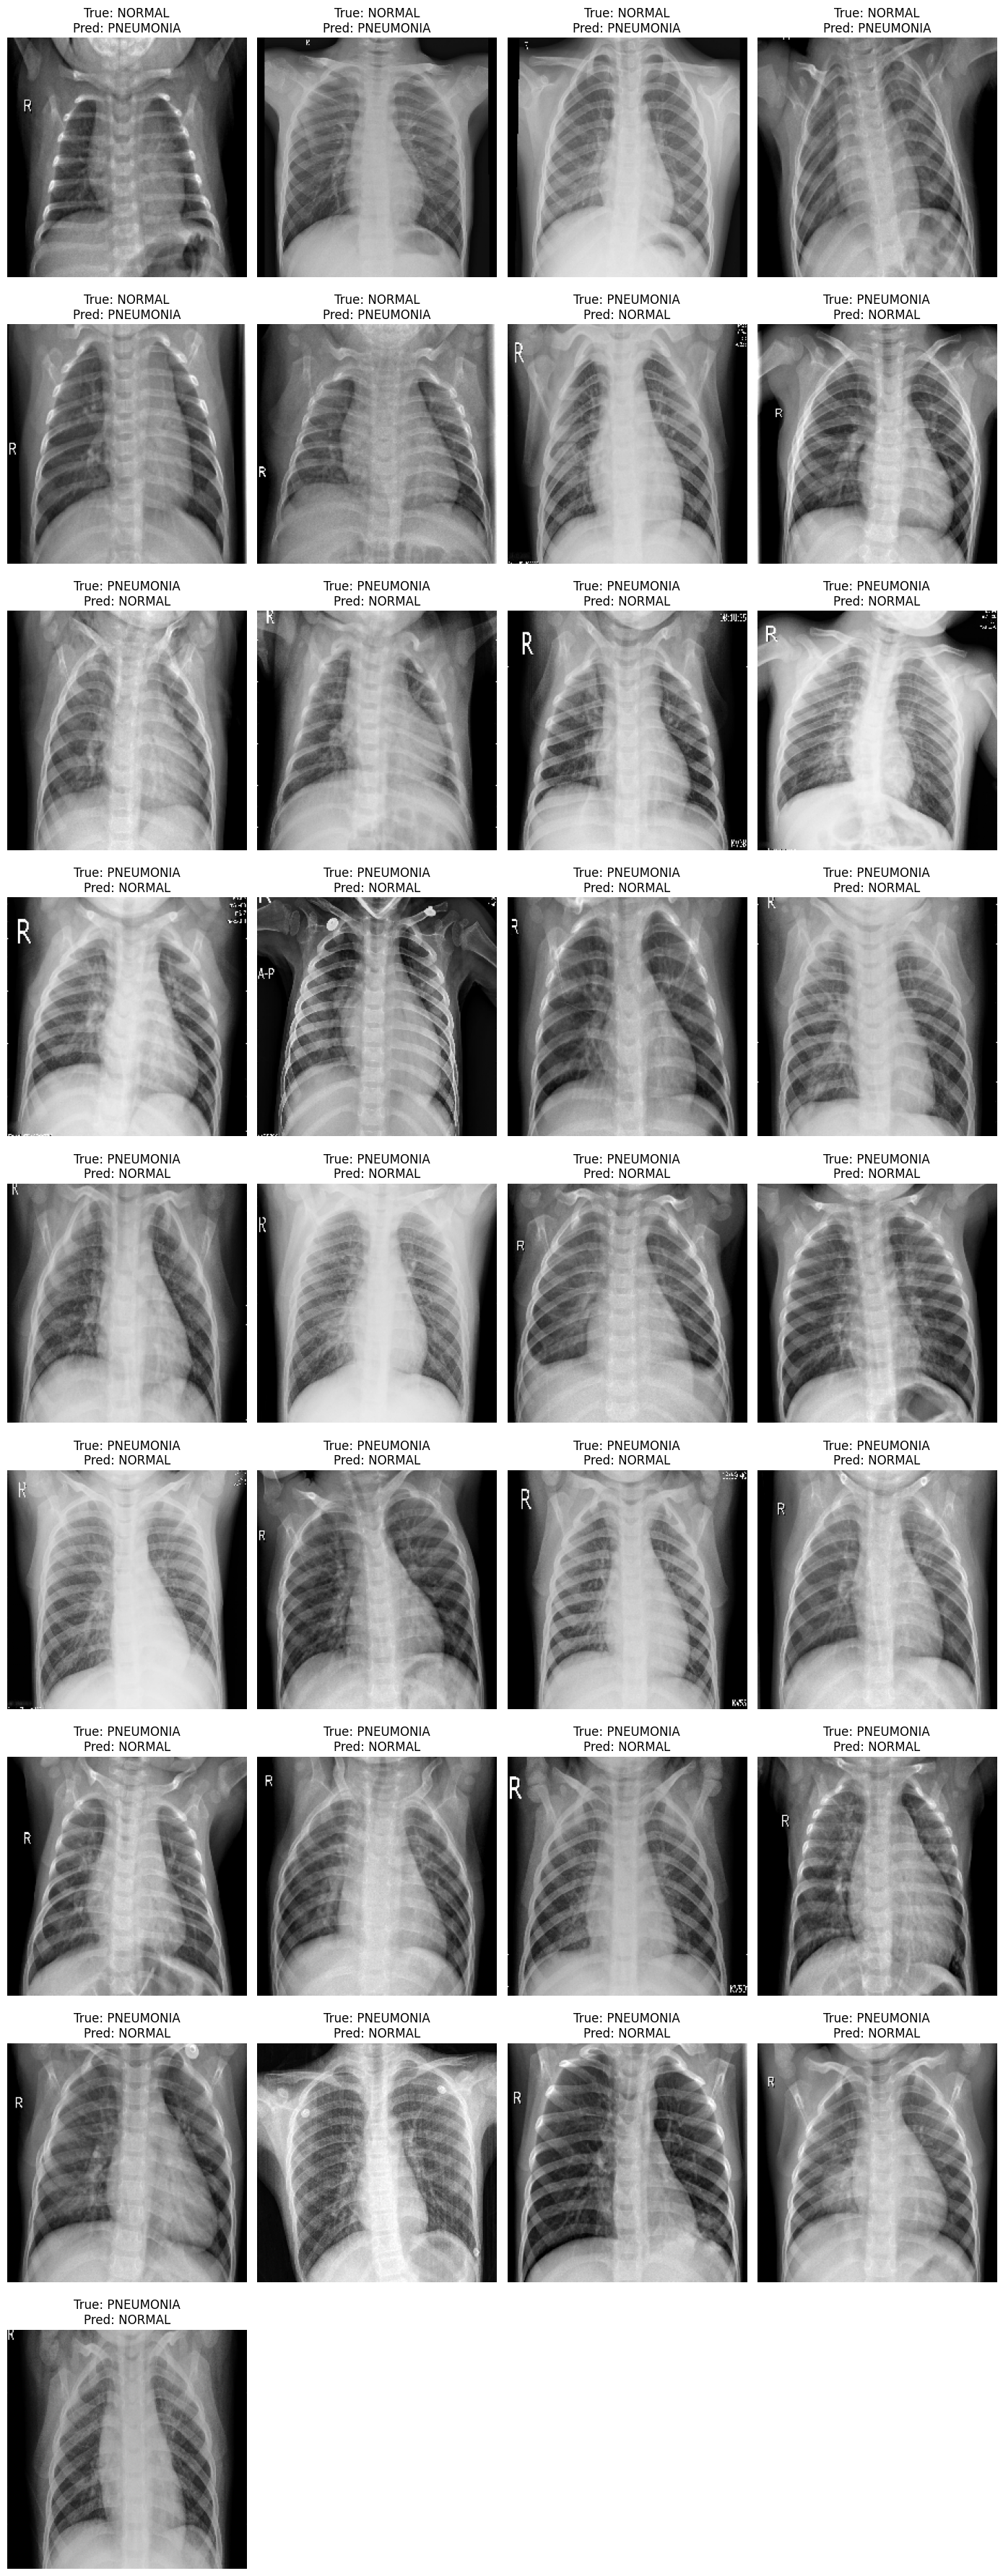

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Predictions
y_pred_prob = model_tl.predict(test_generator_ds)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()
y_true = test_generator_ds.classes

# Class names
class_names = {0: 'NORMAL', 1: 'PNEUMONIA'}

# Get wrong predictions
wrong_indices = np.where(y_pred != y_true)[0]

print("Total wrong predictions:", len(wrong_indices))

# Display wrong images
cols = 4
rows = int(np.ceil(len(wrong_indices) / cols))

plt.figure(figsize=(14, rows * 4))

for i, idx in enumerate(wrong_indices):
    img_path = test_generator_ds.filepaths[idx]

    img = load_img(
        img_path,
        target_size=(224, 224),
        color_mode='grayscale'
    )

    img = img_to_array(img).squeeze() / 255.0

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img, cmap='gray')

    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]

    plt.title(
        f"True: {true_label}\nPred: {pred_label}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()